<a href="https://colab.research.google.com/github/giu-mzx/Checkpoint_02_SERS/blob/main/parte_4_desafio_final/Desafio_Tarefa_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Grupo:**

Andrey Crence Fernandes - RM 573840

Giulliana Maistro Brasolin - RM 569381

Mikaella Mirela Dos Santos Lucindo - RM 573775

Lara Dos Santos Cândido Alves - RM 573827

Lucas Parkin Devito - RM 573251

## **Regressão para Estimativa de Radiação Solar**

Este notebook apresenta a aplicação de modelos de regressão para estimar a radiação solar (`radiacao_w_m2`) a partir de variáveis meteorológicas.

## **Questão - 01**

Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina X (cinco entradas) e y (radiacao_w_m2).



### **Importando Bibliotecas**

In [78]:
# Biblioteca para manipulação e análise dos dados.
import pandas as pd

# Biblioteca para operações numéricas.
import numpy as np

# Bibliotecas para criação e configuração dos gráficos.
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de regressão utilizados no trabalho.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas utilizadas para avaliar as previsões.
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configuração das visualizações.
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## **Carregando e analisando o Dataset**

In [79]:
# Carregando o arquivo CSV para o DataFrame e verificando linhas.
dados = pd.read_csv('https://raw.githubusercontent.com/giu-mzx/Checkpoint_02_SERS/refs/heads/main/datasets/meteo_regressao_orange.csv')
dados.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


## **Análise inicial dos dados**

In [80]:
# Exibindo a quantidade de registros e de variáveis do dataset.
print(f"Quantidade de linhas: {dados.shape[0]}")
print(f"Quantidade de colunas: {dados.shape[1]}")

Quantidade de linhas: 1001
Quantidade de colunas: 7


In [81]:
# Exibindo os tipos de dados e a quantidade de valores não nulos.
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


## **Verificação de valores ausentes e apresentação de Estatísticas Descritivas**

In [82]:
# Contando a quantidade de valores ausentes em cada coluna e mostrando colunas com valores ausentes.

valores_ausentes = dados.isnull().sum()

print("Valores ausentes por coluna:")
print(valores_ausentes[valores_ausentes > 0] if (valores_ausentes > 0).any() else "Nenhum valor ausente encontrado.")



Valores ausentes por coluna:
Nenhum valor ausente encontrado.


In [83]:
# Apresentando medidas estatísticas das variáveis numéricas.

dados.describe()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


### **Explicação das colunas**

O dataset possui 7 colunas e 1001 registros. A coluna `data_hora` representa a data e o horário de cada medição. A coluna `temperatura_c` indica a temperatura em graus Celsius (°C), enquanto `umidade_pct` representa a umidade relativa do ar em porcentagem (%). A coluna `nuvens_pct` indica a porcentagem de cobertura de nuvens, e `vento_kmh` representa a velocidade do vento em quilômetros por hora (km/h). A coluna `hora` indica a hora do dia em que a medição foi realizada. Por fim, `radiacao_w_m2` representa a radiação solar em watts por metro quadrado (W/m²), sendo essa a variável que será prevista pelo modelo.

Não foram encontrados valores ausentes no dataset. Para o modelo de regressão, as cinco variáveis de entrada utilizadas em `X` são `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh` e `hora`, enquanto `radiacao_w_m2` é definida como a variável-alvo `y`.


## **Análise de correlação**

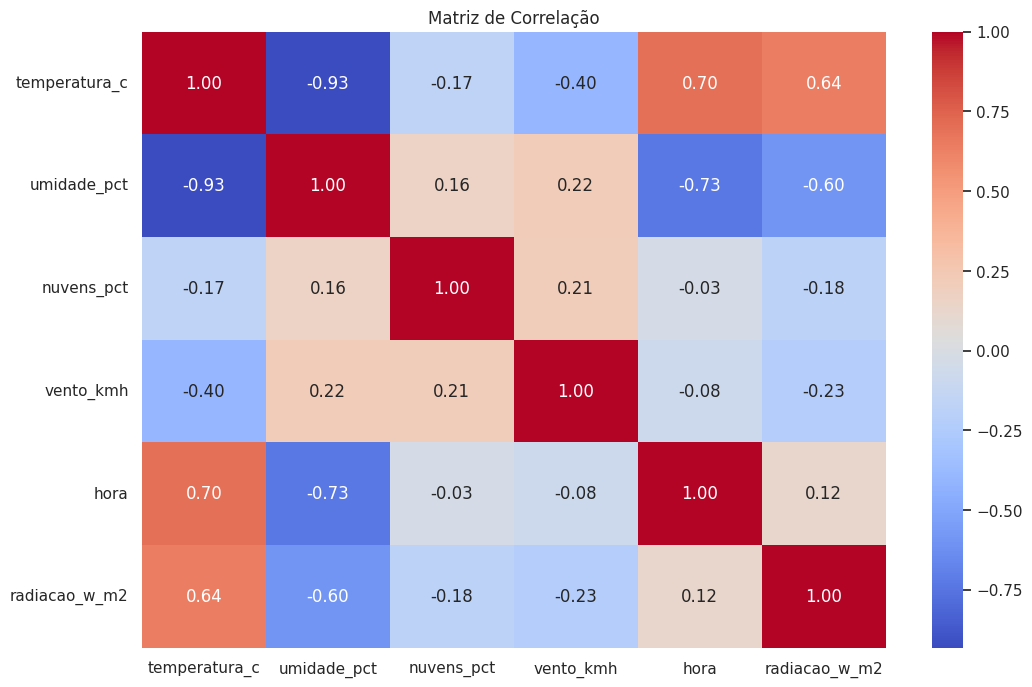

In [84]:
# Calculando a matriz de correlação das variáveis numéricas.
correlacao = dados.select_dtypes(include=[np.number]).corr()

# Exibindo o mapa de calor.
plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

As cinco variáveis selecionadas são: ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']
temperatura_c: correlação original = 0.6427
umidade_pct: correlação original = -0.5962
nuvens_pct: correlação original = -0.1802
vento_kmh: correlação original = -0.2294
hora: correlação original = 0.1201


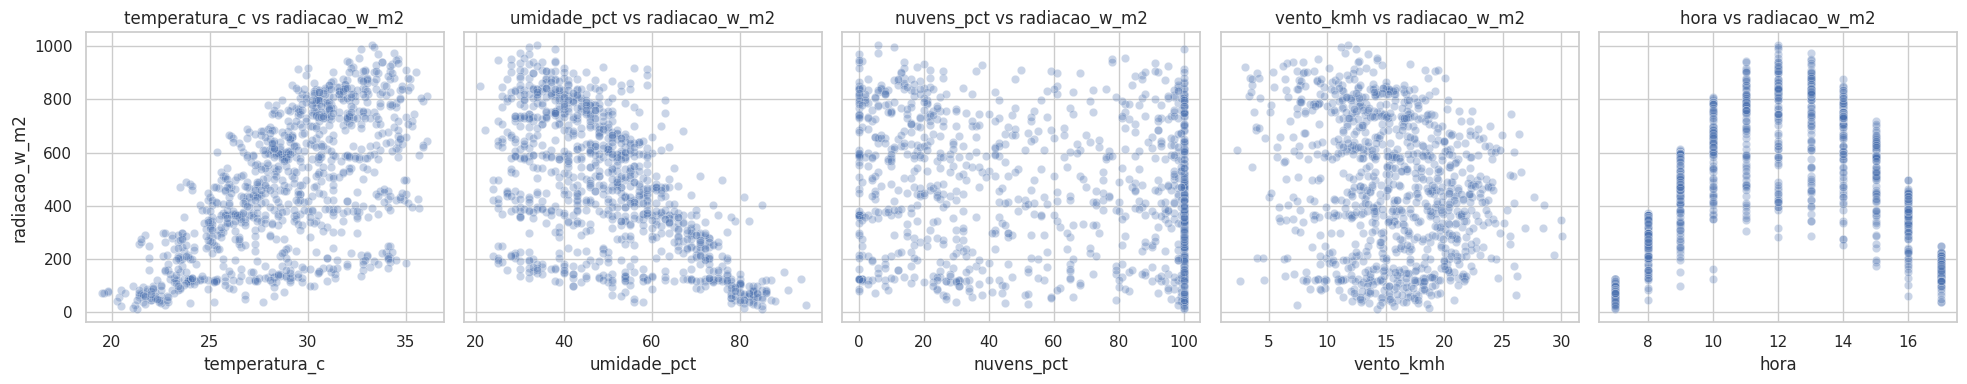

In [85]:
corr_radiacao = correlacao['radiacao_w_m2'].drop('radiacao_w_m2')
cinco_variaveis = ['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']

print("As cinco variáveis selecionadas são:", cinco_variaveis)
for col in cinco_variaveis:
    print(f"{col}: correlação original = {corr_radiacao[col]:.4f}")


fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, col in enumerate(cinco_variaveis):
    sns.scatterplot(data=dados, x=col, y='radiacao_w_m2', ax=axes[i], alpha=0.3)
    axes[i].set_title(f"{col} vs radiacao_w_m2")
plt.tight_layout()
plt.show()

In [86]:
# Definindo variáveis X e Y.
y = dados['radiacao_w_m2']
X = dados[cinco_variaveis]
display(X.head())
display(y.head())

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11


,radiacao_w_m2
0,116.0
1,269.0
2,529.0
3,797.0
4,880.0


## **Questão - 02**

Mantenha as linhas em ordem de data_hora: use aproximadamente 80% das primeiras horas para treino e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.

### **Verificação da ordem cronológica**

In [87]:
# Convertendo a coluna de data e hora para o formato datetime.
dados['data_hora'] = pd.to_datetime(dados['data_hora'])

# Verificando organização dos registros.
print("Dados em ordem cronológica:", dados['data_hora'].is_monotonic_increasing)

Dados em ordem cronológica: True


### **Separação e verificação entre treino e teste**

In [88]:
# Definindo o ponto de corte correspondente a 80% dos registros.
limite = int(len(dados) * 0.8)

# 80% dos registros para treinamento.
X_treino = X.iloc[:limite]
y_treino = y.iloc[:limite]

# 20% finais dos registros para teste.
X_teste = X.iloc[limite:]
y_teste = y.iloc[limite:]

In [89]:
print(f"Treino: {X_treino.shape[0]} registros")
print(f"Teste: {X_teste.shape[0]} registros")

Treino: 800 registros
Teste: 201 registros


In [90]:
# Mostrando os limites temporais de cada conjunto.
print("Primeiro registro:", dados['data_hora'].iloc[0])
print("Último registro do treino:", dados['data_hora'].iloc[limite - 1])
print("Primeiro registro do teste:", dados['data_hora'].iloc[limite])
print("Último registro:", dados['data_hora'].iloc[-1])

Primeiro registro: 2025-04-01 07:00:00
Último registro do treino: 2025-06-12 14:00:00
Primeiro registro do teste: 2025-06-12 15:00:00
Último registro: 2025-06-30 17:00:00


## **Questão - 03**

Escolha, justifique e treine três algoritmos de regressão diferentes com a mesma divisão. Os imports e a implementação são sua responsabilidade.

| Algoritmo | Por que foi escolhido |
|---|---|
|**Regressão Linear** | Modelo de referência (baseline), simples e interpretável. Como a radiação tem formato de sino ao longo do dia, espera-se que o modelo tenha dificuldade em capturar o efeito não linear da `hora`. |
| **Random Forest Regressor** | Conjunto de árvores; captura relações não lineares e interações (ex.: hora × nuvens) sem precisar de padronização; robusto a ruído. |
| **Gradient Boosting Regressor** | Árvores construídas em sequência, cada uma corrigindo os erros da anterior; costuma ter alta precisão em dados tabulares. |

Os três usam **exatamente a mesma divisão**.

In [91]:
# Modelo 1 - Regressão Linear

modelo_linear = LinearRegression()
modelo_linear.fit(X_treino, y_treino)

LinearRegression()

In [92]:
# Modelo 2 - Random Forest Regressor

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
modelo_rf.fit(X_treino, y_treino)

RandomForestRegressor(n_estimators=200, random_state=42)

In [93]:
# Modelo 3 - Gradient Boosting

modelo_gb = GradientBoostingRegressor(
    random_state=42
)
modelo_gb.fit(X_treino, y_treino)


GradientBoostingRegressor(random_state=42)

### **Justificativa para os modelos escolhidos**

Foram escolhidos três algoritmos de regressão diferentes: Regressão Linear, Random Forest Regressor e Gradient Boosting Regressor.

A **Regressão Linear** foi escolhida como modelo de referência por ser simples e interpretável. Como a radiação solar tende a apresentar um comportamento não linear ao longo do dia, esse modelo pode ter dificuldade para representar completamente o efeito da variável `hora`.

O **Random Forest Regressor** foi escolhido por conseguir representar relações não lineares e interações entre as variáveis de entrada, como possíveis relações entre `hora` e `nuvens_pct`, sem a necessidade de padronização dos dados.

O **Gradient Boosting Regressor** também consegue representar relações não lineares e foi escolhido para comparar outro método baseado em árvores com o Random Forest, construindo árvores de forma sequencial, em que cada nova árvore corrige os erros das anteriores.

Os três modelos foram treinados utilizando exatamente a mesma divisão temporal dos dados, com 80% dos registros iniciais para treino e 20% dos registros finais para teste, sem embaralhamento.


## **Questão - 04**
Compare MAE (W/m²), MSE ((W/m²)²) e R²; faça um gráfico de valores reais × previstos de pelo menos um modelo.

### **Previsões**

In [94]:
# Modelo 1 - Regressão Linear
y_previsao_linear = modelo_linear.predict(X_teste)

# Modelo 2 - Random Forest Regressor
y_previsao_rf = modelo_rf.predict(X_teste)

# Modelo 3 - Gradient Boosting
y_previsao_gb = modelo_gb.predict(X_teste)

### **Cálculo das métricas**

In [95]:
# Modelo 1 - Regressão Linear

r2_linear = r2_score(y_teste, y_previsao_linear)
mae_linear = mean_absolute_error(y_teste, y_previsao_linear)
mse_linear = mean_squared_error(y_teste, y_previsao_linear)

print(f"Regressão Linear - R²: {r2_linear:.4f}")
print(f"Regressão Linear - MAE: {mae_linear:.4f} W/m²")
print(f"Regressão Linear - MSE: {mse_linear:.4f} ((W/m²)²)")

Regressão Linear - R²: 0.3598
Regressão Linear - MAE: 145.2049 W/m²
Regressão Linear - MSE: 30034.2011 ((W/m²)²)


In [96]:
# Modelo 2 - Random Forest Regressor

r2_rf = r2_score(y_teste, y_previsao_rf)
mae_rf = mean_absolute_error(y_teste, y_previsao_rf)
mse_rf = mean_squared_error(y_teste, y_previsao_rf)

print(f"Random Forest - R²: {r2_rf:.4f}")
print(f"Random Forest - MAE: {mae_rf:.4f} W/m²")
print(f"Random Forest - MSE: {mse_rf:.4f} ((W/m²)²)")

Random Forest - R²: 0.8455
Random Forest - MAE: 66.2517 W/m²
Random Forest - MSE: 7250.8882 ((W/m²)²)


In [97]:
# Modelo 3 - Gradient Boosting

r2_gb = r2_score(y_teste, y_previsao_gb)
mae_gb = mean_absolute_error(y_teste, y_previsao_gb)
mse_gb = mean_squared_error(y_teste, y_previsao_gb)

print(f"Gradient Boosting - R²: {r2_gb:.4f}")
print(f"Gradient Boosting - MAE: {mae_gb:.4f} W/m²")
print(f"Gradient Boosting - MSE: {mse_gb:.4f} ((W/m²)²)")

Gradient Boosting - R²: 0.8413
Gradient Boosting - MAE: 67.0816 W/m²
Gradient Boosting - MSE: 7444.7002 ((W/m²)²)


### **Tabela comparativa**

In [98]:
# Criação da tabela comparativa dos modelos

comparacao_modelos = pd.DataFrame([
    {
        'Modelo': 'Regressão Linear',
        'Variáveis utilizadas': ', '.join(cinco_variaveis),
        'R²': r2_linear,
        'MAE (W/m²)': mae_linear,
        'MSE ((W/m²)²)': mse_linear
    },
    {
        'Modelo': 'Random Forest',
        'Variáveis utilizadas': ', '.join(cinco_variaveis),
        'R²': r2_rf,
        'MAE (W/m²)': mae_rf,
        'MSE ((W/m²)²)': mse_rf
    },
    {
        'Modelo': 'Gradient Boosting',
        'Variáveis utilizadas': ', '.join(cinco_variaveis),
        'R²': r2_gb,
        'MAE (W/m²)': mae_gb,
        'MSE ((W/m²)²)': mse_gb
    }
])

comparacao_modelos

,Modelo,Variáveis utilizadas,R²,MAE (W/m²),MSE ((W/m²)²)
0,Regressão Linear,"temperatura_c, umidade_pct, nuvens_pct, vento_...",0.359845,145.204885,30034.201092
1,Random Forest,"temperatura_c, umidade_pct, nuvens_pct, vento_...",0.845453,66.251741,7250.888201
2,Gradient Boosting,"temperatura_c, umidade_pct, nuvens_pct, vento_...",0.841322,67.081644,7444.700189


### **Gráficos de valores reais × previstos**


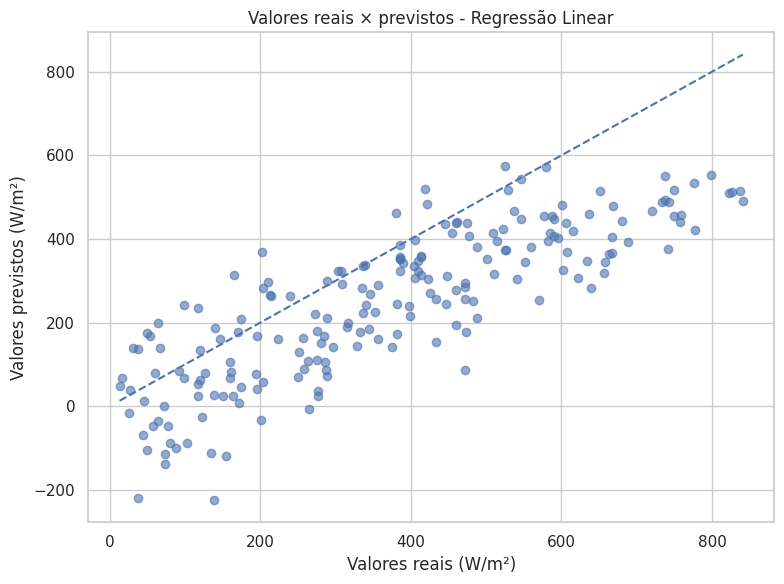

In [99]:
## Modelo 1 - Regressão Linear

plt.figure(figsize=(8, 6))
plt.scatter(y_teste, y_previsao_linear, alpha=0.6)

plt.xlabel('Valores reais (W/m²)')
plt.ylabel('Valores previstos (W/m²)')
plt.title('Valores reais × previstos - Regressão Linear')

plt.plot(
[y_teste.min(), y_teste.max()],
[y_teste.min(), y_teste.max()],
linestyle='--'
)

plt.tight_layout()
plt.show()

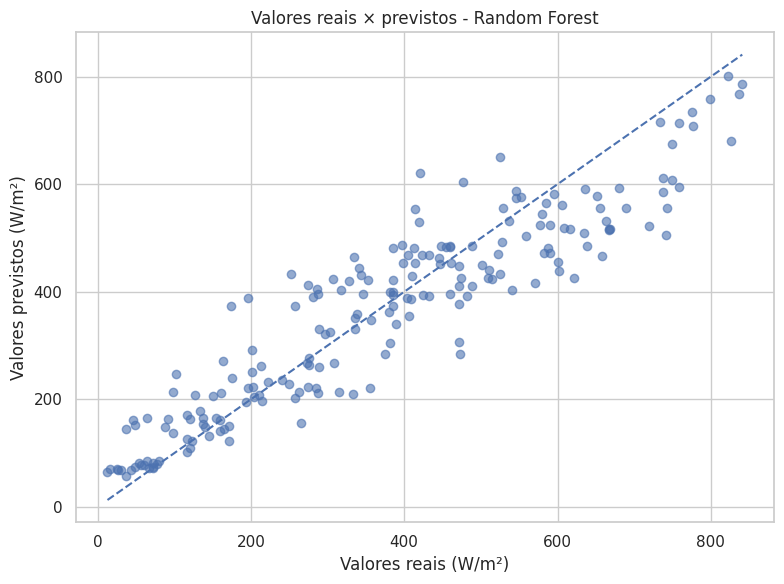

In [100]:
## Modelo 2 - Random Forest

plt.figure(figsize=(8, 6))
plt.scatter(y_teste, y_previsao_rf, alpha=0.6)

plt.xlabel('Valores reais (W/m²)')
plt.ylabel('Valores previstos (W/m²)')
plt.title('Valores reais × previstos - Random Forest')

plt.plot(
[y_teste.min(), y_teste.max()],
[y_teste.min(), y_teste.max()],
linestyle='--'
)

plt.tight_layout()
plt.show()


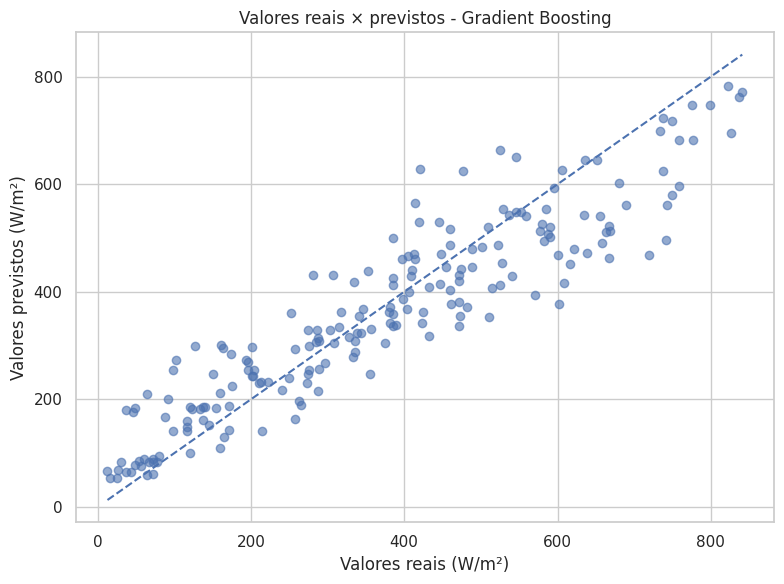

In [101]:
## Modelo 3 - Gradient Boosting

plt.figure(figsize=(8, 6))
plt.scatter(y_teste, y_previsao_gb, alpha=0.6)

plt.xlabel('Valores reais (W/m²)')
plt.ylabel('Valores previstos (W/m²)')
plt.title('Valores reais × previstos - Gradient Boosting')

plt.plot(
[y_teste.min(), y_teste.max()],
[y_teste.min(), y_teste.max()],
linestyle='--'
)

plt.tight_layout()
plt.show()

### **Comparação das métricas**

Os resultados mostram diferenças claras entre os três modelos. A **Regressão Linear** apresentou R² de **0,3598**, MAE de **145,20 W/m²** e MSE de **30.034,20 (W/m²)²**, indicando um desempenho inferior aos modelos baseados em árvores para este conjunto de dados.

O **Random Forest Regressor** apresentou R² de **0,8455**, MAE de **66,25 W/m²** e MSE de **7.250,88 ((W/m²)²)**. Já o **Gradient Boosting Regressor** apresentou R² de **0,8413**, MAE de **67,08 W/m²** e MSE de **7.444,70 ((W/m²)²)**.

Comparando as métricas, os dois modelos baseados em árvores apresentaram resultados bastante próximos e superiores aos da Regressão Linear. O Random Forest apresentou R² ligeiramente maior e valores de MAE e MSE ligeiramente menores que o Gradient Boosting. As diferenças entre os dois foram muito pequenas (R² de 0,8455 contra 0,8413), então os dois podem ser considerados equivalentes nesta divisão. A diferença relevante é entre eles e a Regressão Linear.

De forma geral, os resultados também mostram que os modelos baseados em árvores conseguiram representar melhor as relações não lineares presentes nos dados do que a Regressão Linear.


## **Questão - 05**
Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação não prevê automaticamente a energia produzida por um sistema fotovoltaico.

In [102]:
# Importância de cada variável nos modelos baseados em árvores.
importancias = pd.DataFrame({
    'Variável': cinco_variaveis,
    'Random Forest': modelo_rf.feature_importances_,
    'Gradient Boosting': modelo_gb.feature_importances_
})

importancias.round(3)

,Variável,Random Forest,Gradient Boosting
0,temperatura_c,0.295,0.378
1,umidade_pct,0.179,0.078
2,nuvens_pct,0.022,0.014
3,vento_kmh,0.016,0.009
4,hora,0.488,0.522


## **Interpretação dos erros e limitações da estimativa**




### **Interpretação dos erros**

Os resultados mostram que a Regressão Linear apresentou erros maiores, com MAE de 145,20 W/m² e MSE de 30.034,20 (W/m²)², além de R² de 0,3598. Isso indica que o modelo linear teve mais dificuldade para representar o comportamento da radiação solar. Os modelos baseados em árvores apresentaram erros consideravelmente menores: o Random Forest teve MAE de 66,25 W/m² e MSE de 7.250,88 ((W/m²)²), enquanto o Gradient Boosting apresentou MAE de 67,08 W/m² e MSE de 7.444,70 ((W/m²)²). Os valores de R², próximos de 0,84, indicam que esses modelos conseguiram explicar uma parcela maior da variação da radiação no conjunto de teste.

### **Peso da variável hora**

A variável hora foi a mais importante nos dois modelos de árvore: cerca de 49% da importância no Random Forest e 52% no Gradient Boosting. Em seguida vieram a temperatura (30% e 38%) e a umidade (18% e 8%), enquanto nuvens_pct e vento_kmh pesaram pouco. Isso é interessante porque, na análise de correlação, a hora tinha a relação linear mais fraca com a radiação (0,12). Isso acontece porque a radiação não sobe em linha reta ao longo do dia: ela começa baixa às 7h, chega ao pico perto do meio-dia e volta a cair até as 17h. A correlação só mede relações lineares, então não captura bem esse formato, e a Regressão Linear também tem dificuldade com ele. Já os modelos de árvore conseguem separar o dia em faixas de horário, o que explica o melhor desempenho deles.

### **Radiação solar × energia fotovoltaica**

Entretanto, a estimativa da radiação solar não representa automaticamente a energia produzida por um sistema fotovoltaico. A radiação é uma medida de potência solar incidente por área, expressa em W/m², enquanto a energia produzida depende de outros fatores e é normalmente expressa em Wh ou kWh. Para estimar a geração de um sistema fotovoltaico, seria necessário considerar características como a potência instalada dos painéis, a área e a eficiência dos módulos, além de perdas do sistema, temperatura dos painéis, orientação e inclinação dos módulos, sombreamento e eficiência do inversor.

## **Conclusão**

Portanto, os modelos desenvolvidos são capazes de estimar a radiação solar, mas essa previsão não deve ser interpretada diretamente como uma previsão da energia elétrica gerada por um sistema fotovoltaico. Seria necessário um modelo adicional que relacionasse a radiação estimada às características e às condições de operação do sistema fotovoltaico.